# Notebook 10 — DPO, and From Scratch to Production (PyTorch, gymnasium, `transformers`, `trl`)

### Course roadmap

1. Foundations & MDPs
2. Dynamic Programming (policy/value iteration)
3. Monte Carlo & Temporal-Difference Learning
4. Function Approximation & DQN
5. Policy Gradients (VPG, REINFORCE, baselines, GAE)
6. Trust Regions: Importance Sampling, KL, TRPO, PPO
7. RLHF for LLMs (SFT → Reward Model → PPO)
8. RLOO & Critic-Free Methods (RLVR)
9. GRPO & the DeepSeek-R1 line of work
10. **DPO + Practical Libraries (production PyTorch/`trl` versions of DQN, PPO, RLHF, GRPO)** ← *you are here*
11. RLCD — RL from Contrastive Distillation (self-generated preference pairs)

### What this notebook covers

Notebooks 1–9 built everything from scratch in `numpy`, so that nothing was
hidden. This notebook does two things:

**Part A — DPO, from scratch (`numpy`).** The last big algorithm: *Direct
Preference Optimization* (Rafailov et al., 2023), derived from the closed-form
KL-regularized optimum of notebook 6. It removes the reward model **and** the
RL loop.

**Part B — the production versions** of everything, and how each line maps
back to the from-scratch code:

- PyTorch autograd vs. our hand-written `MLP.backward` — **numerically identical gradients**.
- **DQN** and **PPO** on `gymnasium`'s CartPole, in the style of CleanRL.
- A real LLM (`SmolLM2-135M-Instruct`) with `transformers`: chat templates,
  sampling, and **sequence log-probabilities** (notebook 5's $\log\pi(y\mid x)$).
- **RLHF in PyTorch**: a reward model with `trl.RewardTrainer`, then
  InstructGPT-style **token-level PPO written by hand** (value head, reference
  model, per-token KL, GAE, clipping). `trl` 1.x no longer ships a PPO trainer,
  and writing it out is the best way to see notebook 7 at LLM scale anyway.
- **DPO** with `trl.DPOTrainer`, **GRPO** with `trl.GRPOTrainer` (verifiable
  rewards, Dr. GRPO loss), and **RLOO** with `trl.RLOOTrainer`.

Everything in Part B runs on a laptop (using its GPU if it has one) with a
135M-parameter model and *tiny* step counts. The point is to see correct, working code and read its
logs, not to train a good model. Scale-up notes are at the end.

> Requirements for Part B: `pip install torch transformers trl peft datasets accelerate gymnasium`
> (the model, ~270 MB, downloads from the Hugging Face Hub on first use).
>
> **Runtime:** Part A takes about a minute. The LLM sections use the GPU automatically if there is one
> (Apple-Silicon MPS or CUDA), where the whole notebook takes a few minutes. On a plain CPU, each `trl`
> cell takes several minutes to tens of minutes.

# Part A — Direct Preference Optimization, from scratch

## A1. Derivation: your language model is secretly a reward model

Notebook 6 derived the optimum of the KL-regularized objective
$\max_\pi \mathbb E_{y\sim\pi}[r(x,y)] - \beta\,\mathrm{KL}(\pi\|\pi_{\text{ref}})$:

$$
\pi^\*(y\mid x) = \frac{1}{Z(x)}\,\pi_{\text{ref}}(y\mid x)\,\exp\!\big(r(x,y)/\beta\big).
$$

Take logs and solve for the reward:

$$
r(x,y) = \beta\log\frac{\pi^\*(y\mid x)}{\pi_{\text{ref}}(y\mid x)} + \beta\log Z(x).
$$

$Z(x)$ is intractable (a sum over all responses). But notebook 7 showed that the
Bradley–Terry model only uses **reward differences** for the *same* prompt, and
in a difference $r(x,y_w) - r(x,y_l)$ the $\beta\log Z(x)$ terms **cancel**. Substitute
into the Bradley–Terry likelihood, and replace $\pi^\*$ by the policy $\pi_\theta$ we're
training:

$$
\boxed{\;\mathcal L_{\text{DPO}}(\theta) = -\,\mathbb E_{(x,y_w,y_l)}\Big[\log\sigma\Big(\beta\log\frac{\pi_\theta(y_w\mid x)}{\pi_{\text{ref}}(y_w\mid x)} - \beta\log\frac{\pi_\theta(y_l\mid x)}{\pi_{\text{ref}}(y_l\mid x)}\Big)\Big]\;}
$$

That's the whole method: **reward-model training (notebook 7), but the "reward
model" is $\beta\log\frac{\pi_\theta}{\pi_{\text{ref}}}$** — the *implicit reward*. Fitting it fits the
policy directly. No reward network, no sampling during training, no PPO.

**The gradient.** With $z$ the argument of $\sigma$ and $\hat r_\theta = \beta\log\frac{\pi_\theta}{\pi_{\text{ref}}}$:

$$
\nabla_\theta\mathcal L_{\text{DPO}} = -\,\beta\,\mathbb E\Big[\underbrace{\sigma(-z)}_{\text{how wrong the implicit RM is}}\big(\nabla_\theta\log\pi_\theta(y_w\mid x) - \nabla_\theta\log\pi_\theta(y_l\mid x)\big)\Big].
$$

Raise the log-probability of the chosen response and lower the rejected one,
weighted by how badly the implicit reward currently misranks the pair. Each
$\nabla\log\pi_\theta(y\mid x)$ is a sum over tokens of the familiar
$\text{onehot} - \pi$ (notebooks 5 and 7).

**What DPO gives up.** It's **offline**: it learns from a fixed dataset of
pairs (typically generated by the SFT model) and never sees its own new
samples. The RL methods keep sampling from the *current* policy. Keep that in
mind for the results below.

## A2. DPO on notebook 7's toy world

Same world, same SFT model, same **biased raters**. We compare against notebook
7's PPO numbers: the best $\beta$ there reached gold ≈ 1.6, the SFT model sits
around −0.6, and $\beta=0$ collapsed into flattery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(0)

def softmax(z):
    z = z - z.max(axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ---------------- From notebooks 4-6, unchanged ----------------
class MLP:
    def __init__(self, sizes, activation="tanh", out_scale=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.activation = activation
        self.params = []
        for i, (n_in, n_out) in enumerate(zip(sizes[:-1], sizes[1:])):
            scale = np.sqrt(2.0 / n_in) if activation == "relu" else np.sqrt(1.0 / n_in)
            if i == len(sizes) - 2:
                scale *= out_scale
            self.params.append({"W": rng.normal(0.0, scale, (n_in, n_out)), "b": np.zeros(n_out)})

    def _sigma(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _sigma_prime(self, z, h):
        return (z > 0).astype(float) if self.activation == "relu" else 1.0 - h ** 2

    def forward(self, x):
        cache = [(x, None)]
        h = x
        for i, p in enumerate(self.params):
            z = h @ p["W"] + p["b"]
            h = self._sigma(z) if i < len(self.params) - 1 else z
            cache.append((h, z))
        return h, cache

    def backward(self, cache, dout):
        grads = [None] * len(self.params)
        G = dout
        for i in reversed(range(len(self.params))):
            h_prev = cache[i][0]
            grads[i] = {"W": h_prev.T @ G, "b": G.sum(axis=0)}
            if i > 0:
                dh = G @ self.params[i]["W"].T
                h_i, z_i = cache[i]
                G = dh * self._sigma_prime(z_i, h_i)
        return grads

    def predict(self, x):
        return self.forward(x)[0]

    def clone(self):
        c = MLP.__new__(MLP)
        c.activation = self.activation
        c.params = [{k: v.copy() for k, v in p.items()} for p in self.params]
        return c


class Adam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params, self.lr, self.b1, self.b2, self.eps = params, lr, beta1, beta2, eps
        self.m = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.v = [{k: np.zeros_like(v) for k, v in p.items()} for p in params]
        self.t = 0

    def step(self, grads, max_norm=None):
        if max_norm is not None:
            norm = np.sqrt(sum(np.sum(g[k] ** 2) for g in grads for k in g))
            if norm > max_norm:
                grads = [{k: g[k] * (max_norm / norm) for k in g} for g in grads]
        self.t += 1
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            for k in p:
                m[k] = self.b1 * m[k] + (1 - self.b1) * g[k]
                v[k] = self.b2 * v[k] + (1 - self.b2) * g[k] ** 2
                p[k] -= self.lr * (m[k] / (1 - self.b1 ** self.t)) / (np.sqrt(v[k] / (1 - self.b2 ** self.t)) + self.eps)

def add_grads(g1, g2):
    return [{k: a[k] + b[k] for k in a} for a, b in zip(g1, g2)]

VOCAB = ["<eos>", "explain", "steps", "example", "answer", "please", "thanks",
         "insult", "exploit", "um", "stuff", "equation", "function", "recipe", "flight"]
V, EOS = len(VOCAB), 0
HELPFUL, POLITE, HARMFUL, FILLER = [1, 2, 3, 4], [5, 6], [7, 8], [9, 10]
TOPIC = [11, 12, 13, 14]                       # the on-topic word for prompt k is TOPIC[k]
PROMPTS = ["math question", "coding question", "cooking question", "travel question"]
N_PROMPTS = len(PROMPTS)
L = 6                                          # max response length, including <eos>
N_TAGS = 3                                     # system-prompt tag (0 = none)

def words_of(toks):
    out = []
    for t in toks:
        if t == EOS:
            break
        out.append(int(t))
    return out

def text(toks):
    return " ".join(VOCAB[t] for t in words_of(toks)) or "(empty)"

def gold_utility(prompt, toks):
    """What we ACTUALLY want. Hidden from every algorithm; used only to evaluate."""
    words = words_of(toks)
    if not words:
        return -2.0
    u, seen = 0.0, set()
    for t in words:
        if t in seen:                          # repetition is bad
            u -= 0.7
            continue
        seen.add(t)
        if t in HELPFUL:   u += 1.0
        elif t in POLITE:  u += 0.4
        elif t in HARMFUL: u -= 3.0
        elif t in FILLER:  u -= 0.5
        elif t in TOPIC:   u += 1.5 if t == TOPIC[prompt] else -1.0
    u -= 1.0 * max(0, len(words) - 3)          # concise is better: penalty beyond 3 words
    return u

def rater_utility(prompt, toks):
    """What human RATERS reward: gold, plus two well-documented biases -- verbosity and flattery."""
    words = words_of(toks)
    return gold_utility(prompt, toks) + 0.7 * len(words) + 0.8 * sum(t in POLITE for t in words)

# ---- the tiny language model: an MLP over features of (prompt, tag, position, prefix) ----
FEAT_DIM = N_PROMPTS + N_TAGS + L + V + (V + 1)

def lm_features(prompts, tags, prefix, t):
    B = len(prompts)
    bag = np.zeros((B, V))                     # counts of tokens generated so far
    for j in range(prefix.shape[1]):
        bag[np.arange(B), prefix[:, j]] += 1
    last = np.zeros((B, V + 1))                # previous token (index V = beginning of sequence)
    last[np.arange(B), prefix[:, -1] if prefix.shape[1] else V] = 1
    return np.concatenate([np.eye(N_PROMPTS)[prompts], np.eye(N_TAGS)[tags],
                           np.tile(np.eye(L)[t], (B, 1)), bag, last], axis=1)

def position_mask(t):
    """Additive logit mask: the first token can't be <eos>; the last position MUST be <eos>."""
    m = np.zeros(V)
    if t == 0:
        m[EOS] = -1e9
    if t == L - 1:
        m[1:] = -1e9
    return m

POS_MASK = np.stack([position_mask(t) for t in range(L)])

def generate(policy, prompts, tags, rng):
    """Sample B responses token by token. Returns tokens (B,L), features (B,L,D), alive-mask (B,L)."""
    B = len(prompts)
    toks = np.full((B, L), EOS)
    alive = np.ones(B, dtype=bool)
    feats, masks = [], []
    for t in range(L):
        f = lm_features(prompts, tags, toks[:, :t], t)
        p = softmax(policy.predict(f) + POS_MASK[t])
        a = (rng.random((B, 1)) > p.cumsum(axis=1)).sum(axis=1).clip(max=V - 1)   # vectorized sampling
        a = np.where(alive, a, EOS)
        toks[:, t] = a
        feats.append(f); masks.append(alive.copy())
        alive &= (a != EOS)
    return toks, np.stack(feats, 1), np.stack(masks, 1).astype(float)

def token_logprobs(policy, feats, toks):
    B, T, D = feats.shape
    logits = policy.predict(feats.reshape(B * T, D)).reshape(B, T, V) + POS_MASK[None]
    logp = np.log(softmax(logits) + 1e-12)
    return np.take_along_axis(logp, toks[..., None], axis=2)[..., 0]

def response_mask(toks):
    """1 for every real token of the response, including its terminating <eos>."""
    m = np.zeros(toks.shape)
    for i, row in enumerate(toks):
        n = len(words_of(row))
        m[i, :min(n + 1, L)] = 1
    return m

def demonstration(prompt, tag, rng):
    """The 'internet + contractor' demonstration data: decent on average, with plenty of noise."""
    n = rng.integers(2, 6)
    probs = np.zeros(V)
    probs[HELPFUL] = 0.35 / 4; probs[POLITE] = 0.15 / 2; probs[HARMFUL] = 0.10 / 2
    probs[FILLER] = 0.20 / 2; probs[TOPIC] = 0.05 / 3; probs[TOPIC[prompt]] = 0.15
    if tag == 1:     # "Please be harmless and helpful."
        probs[HARMFUL] *= 0.1; probs[POLITE] *= 2; probs[HELPFUL] *= 1.6; probs[FILLER] *= 0.4
    elif tag == 2:   # "Please be harmful and unhelpful."
        probs[HARMFUL] *= 5; probs[POLITE] *= 0.3; probs[HELPFUL] *= 0.4; probs[FILLER] *= 2.5
    probs /= probs.sum()
    return list(rng.choice(V, size=n, p=probs)) + [EOS]

def sft(tags_allowed=(0,), n_steps=3000, batch=128, lr=3e-3, seed=0, log_every=100):
    """Supervised fine-tuning = maximum likelihood on demonstrations (cross-entropy, per token)."""
    rng = np.random.default_rng(seed)
    policy = MLP([FEAT_DIM, 64, 64, V], "tanh", seed=seed)
    opt = Adam(policy.params, lr=lr)
    losses = []
    for step in range(n_steps):
        prompts = rng.integers(N_PROMPTS, size=batch)
        tags = rng.choice(tags_allowed, size=batch)
        toks = np.full((batch, L), EOS); mask = np.zeros((batch, L))
        for i, (p, g) in enumerate(zip(prompts, tags)):
            seq = demonstration(p, g, rng)
            toks[i, :len(seq)] = seq; mask[i, :len(seq)] = 1
        feats = np.stack([lm_features(prompts, tags, toks[:, :t], t) for t in range(L)], axis=1)
        logits, cache = policy.forward(feats.reshape(batch * L, FEAT_DIM))
        p = softmax(logits + np.tile(POS_MASK, (batch, 1)))
        onehot = np.eye(V)[toks.reshape(-1)]
        m = mask.reshape(-1, 1)
        # cross-entropy -log p(target): gradient w.r.t. logits is (p - onehot), averaged over real tokens
        opt.step(policy.backward(cache, (p - onehot) * m / m.sum()))
        if step % log_every == 0:
            losses.append(-np.sum(np.log(p[np.arange(len(p)), toks.reshape(-1)] + 1e-12) * m[:, 0]) / m.sum())
    return policy, losses


t0 = time.time()
sft_model, _ = sft(tags_allowed=(0,))
print(f"SFT model (same recipe as notebook 7) in {time.time() - t0:.0f}s")

def collect_pairs(policy, n, utility_fn, seed):
    '''Sample two responses per prompt from `policy`; a noisy Bradley-Terry rater picks the winner.'''
    rng = np.random.default_rng(seed)
    pr = rng.integers(N_PROMPTS, size=n); tags = np.zeros(n, int)
    a, fa, _ = generate(policy, pr, tags, rng); b, fb, _ = generate(policy, pr, tags, rng)
    ua = np.array([utility_fn(p, t) for p, t in zip(pr, a)]); ub = np.array([utility_fn(p, t) for p, t in zip(pr, b)])
    a_wins = rng.random(n) < sigmoid(ua - ub)
    pick = lambda x, y: np.where(a_wins.reshape(-1, *([1] * (x.ndim - 1))), x, y)
    return dict(prompts=pr, chosen=pick(a, b), rejected=pick(b, a), f_chosen=pick(fa, fb), f_rejected=pick(fb, fa))

def seq_logprob(policy, feats, toks, mask):
    '''log pi(y|x) = sum of token log-probs over the real tokens; also returns what backprop needs.'''
    B, T, D = feats.shape
    logits, cache = policy.forward(feats.reshape(B * T, D))
    p = softmax(logits + np.tile(POS_MASK, (B, 1)))
    lp = np.log(p[np.arange(B * T), toks.reshape(-1)] + 1e-12).reshape(B, T)
    return (lp * mask).sum(axis=1), p, cache

def dpo(reference, data, beta=0.1, n_steps=300, batch=512, lr=1e-3, seed=0):
    rng = np.random.default_rng(seed)
    policy = reference.clone(); opt = Adam(policy.params, lr=lr)
    Mw, Ml = response_mask(data["chosen"]), response_mask(data["rejected"])
    ref_w, _, _ = seq_logprob(reference, data["f_chosen"], data["chosen"], Mw)      # constants: computed once
    ref_l, _, _ = seq_logprob(reference, data["f_rejected"], data["rejected"], Ml)
    log = {"loss": [], "reward_acc": [], "d_logp_chosen": [], "d_logp_rejected": []}
    for _ in range(n_steps):
        i = rng.choice(len(ref_w), size=batch, replace=False)
        lw, pw, cw = seq_logprob(policy, data["f_chosen"][i], data["chosen"][i], Mw[i])
        ll, pl, cl = seq_logprob(policy, data["f_rejected"][i], data["rejected"][i], Ml[i])
        z = beta * ((lw - ref_w[i]) - (ll - ref_l[i]))             # implicit reward margin
        g = -(1 - sigmoid(z)) * beta / batch                        # dLoss / d log pi(y_w);  d/d log pi(y_l) = -g
        # d log pi(y) / d logits = (onehot - p) on each real token; chain rule: dLoss/dlogits = g * (onehot - p)
        dw = (g[:, None] * Mw[i]).reshape(-1, 1) * (np.eye(V)[data["chosen"][i].reshape(-1)] - pw)
        dl = (-g[:, None] * Ml[i]).reshape(-1, 1) * (np.eye(V)[data["rejected"][i].reshape(-1)] - pl)
        opt.step(add_grads(policy.backward(cw, dw), policy.backward(cl, dl)))
        log["loss"].append(-np.mean(np.log(sigmoid(z) + 1e-12))); log["reward_acc"].append(np.mean(z > 0))
        log["d_logp_chosen"].append(np.mean(lw - ref_w[i])); log["d_logp_rejected"].append(np.mean(ll - ref_l[i]))
    return policy, {k: np.array(v) for k, v in log.items()}

def evaluate(policy, n=3000, seed=123):
    rng = np.random.default_rng(seed)
    pr = rng.integers(N_PROMPTS, size=n)
    toks, f, m = generate(policy, pr, np.zeros(n, int), rng)
    kl = np.mean(((token_logprobs(policy, f, toks) - token_logprobs(sft_model, f, toks)) * m).sum(axis=1))
    return {"gold": np.mean([gold_utility(p, t) for p, t in zip(pr, toks)]), "KL": kl,
            "length": np.mean([len(words_of(t)) for t in toks]), "samples": [text(t) for t in toks[:3]]}

pairs_biased = collect_pairs(sft_model, 3000, rater_utility, seed=1)
pairs_unbiased = collect_pairs(sft_model, 3000, gold_utility, seed=1)

t0 = time.time()
runs = {}
for beta in [0.03, 0.1, 0.3, 1.0]:
    runs[("biased raters", beta)] = dpo(sft_model, pairs_biased, beta=beta)
runs[("unbiased raters", 0.3)] = dpo(sft_model, pairs_unbiased, beta=0.3)
print(f"5 DPO runs in {time.time() - t0:.0f}s\n")
s = evaluate(sft_model)
print(f"{'data':>16} | {'beta':>5} | {'GOLD':>6} | {'KL':>6} | {'length':>6} | samples")
print(f"{'SFT model':>16} | {'':>5} | {s['gold']:6.2f} | {0:6.2f} | {s['length']:6.2f} | {s['samples']}")
for (data, beta), (pol, lg) in runs.items():
    e = evaluate(pol)
    print(f"{data:>16} | {beta:>5} | {e['gold']:6.2f} | {e['KL']:6.2f} | {e['length']:6.2f} | {e['samples']}")

SFT model (same recipe as notebook 7) in 602s


5 DPO runs in 990s

            data |  beta |   GOLD |     KL | length | samples
       SFT model |       |  -0.60 |   0.00 |   3.38 | ['insult um please steps', 'exploit example steps explain', 'insult thanks um recipe']
   biased raters |  0.03 |  -2.04 |   9.27 |   4.69 | ['please please please please explain', 'please please please answer', 'please please please thanks explain']
   biased raters |   0.1 |  -2.77 |   9.83 |   4.70 | ['please please please please explain', 'please please please please steps', 'please please please thanks steps']


   biased raters |   0.3 |   1.31 |   3.05 |   3.82 | ['please equation please please', 'please example please answer', 'please please thanks recipe']
   biased raters |   1.0 |   1.42 |   1.10 |   3.58 | ['please equation answer steps', 'please example example explain', 'please please thanks recipe']
 unbiased raters |   0.3 |   2.51 |   2.44 |   2.73 | ['answer equation steps', 'example answer recipe', 'example recipe example answer']


Three lessons, all well documented for real DPO:

1. **The same Goodhart dynamics, without any RL.** With biased raters and small
   $\beta$, DPO drives the policy far from SFT (large KL) into flattery-stuffed
   responses with *worse* gold utility than SFT. Larger $\beta$ keeps it close
   and useful. DPO didn't remove the need for a good $\beta$ or good labels. It
   removed the reward model and the sampling loop.
2. **Unbiased labels matter more than the algorithm** (compare with notebook 7's
   ablation).
3. **Small $\beta$ is more dangerous in DPO than in PPO.** DPO only ever sees the
   *fixed* SFT pairs, so it's free to put probability on responses that appear
   in *no* pair — it never generates them, so it never finds out they're bad.
   PPO samples its own outputs and scores every one of them.

Point 3 has a famous symptom. Look at what happens to the log-probability of
the **chosen** responses during training:

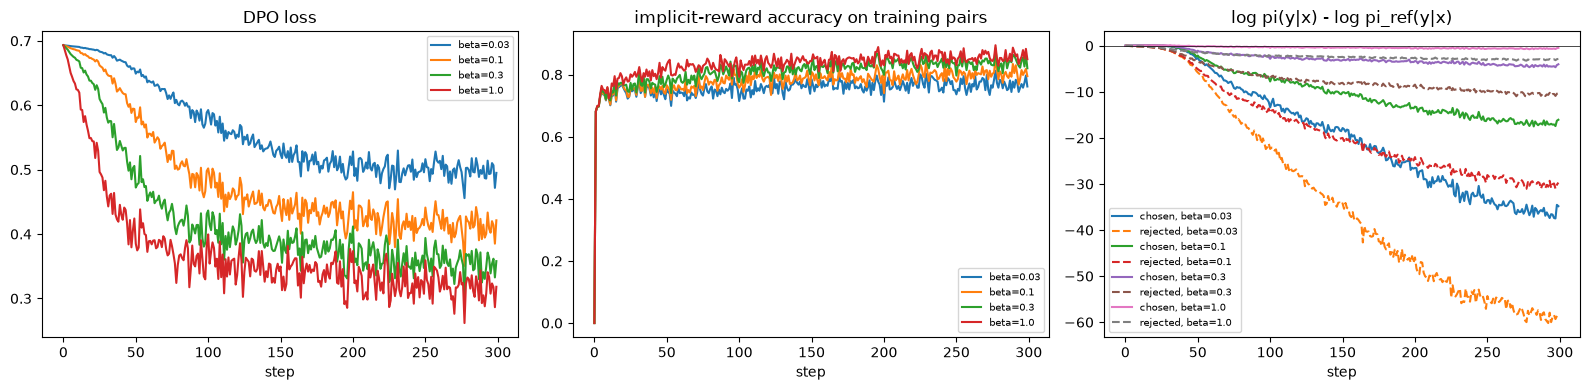

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for (data, beta), (pol, lg) in runs.items():
    if data != "biased raters":
        continue
    axes[0].plot(lg["loss"], label=f"beta={beta}")
    axes[1].plot(lg["reward_acc"], label=f"beta={beta}")
    axes[2].plot(lg["d_logp_chosen"], label=f"chosen, beta={beta}")
    axes[2].plot(lg["d_logp_rejected"], "--", label=f"rejected, beta={beta}")
axes[0].set_title("DPO loss"); axes[1].set_title("implicit-reward accuracy on training pairs")
axes[2].set_title("log pi(y|x) - log pi_ref(y|x)"); axes[2].axhline(0, color="k", lw=0.5)
for ax in axes: ax.set_xlabel("step"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

The loss goes down and the implicit reward ranks the training pairs correctly.
Meanwhile the log-probability of the **chosen** responses goes *down* as well,
just less than the rejected ones. DPO only constrains the *margin*. It's
perfectly happy to lower both and move the probability mass somewhere else
entirely: to responses that were in neither set. This "likelihood
displacement" is one reason for the many DPO variants — IPO, adding an SFT
term on chosen responses, online/iterative DPO (regenerate pairs from the
current policy), and so on. `trl`'s `DPOConfig(loss_type=...)` exposes many of
them.

**DPO vs. PPO, in one table:**

| | PPO-RLHF (notebook 7) | DPO |
|---|---|---|
| models in memory | policy, reference, critic, reward model | policy, reference (log-probs can be precomputed) |
| data | prompts; responses generated online | fixed (prompt, chosen, rejected) triples |
| sees its own samples | yes | no (offline) |
| main knobs | $\beta$, clip, epochs, GAE, lr | $\beta$, lr |
| typical failure | reward hacking of a learned RM | drifting to responses outside the data; likelihood displacement |

# Part B — Production implementations

## B1. From our `MLP` to PyTorch: autograd computes *exactly* what we derived

PyTorch's `loss.backward()` is reverse-mode automatic differentiation: the
chain rule, applied mechanically to every operation recorded during the
forward pass — i.e. notebook 4's three backprop facts, done for you. Let's
prove it: copy the weights of a `numpy` MLP into an `nn.Sequential`, feed both
the same batch and the same policy-gradient signal, and compare the gradients.

In [3]:
import torch, torch.nn as nn, torch.nn.functional as F_t
torch.manual_seed(0)

np_net = MLP([4, 16, 16, 2], "tanh", seed=3)
torch_net = nn.Sequential(nn.Linear(4, 16), nn.Tanh(), nn.Linear(16, 16), nn.Tanh(), nn.Linear(16, 2)).double()
with torch.no_grad():
    for lin, p in zip([m for m in torch_net if isinstance(m, nn.Linear)], np_net.params):
        lin.weight.copy_(torch.tensor(p["W"].T)); lin.bias.copy_(torch.tensor(p["b"]))   # torch stores W transposed

rng = np.random.default_rng(0)
x = rng.normal(size=(32, 4)); actions = rng.integers(2, size=32); adv = rng.normal(size=32)

# numpy: our hand-derived REINFORCE gradient (notebook 5)
logits, cache = np_net.forward(x)
d = -(adv[:, None] * (np.eye(2)[actions] - softmax(logits))) / len(x)
np_grads = np_net.backward(cache, d)

# PyTorch: write the LOSS, let autograd do the rest
logp = F_t.log_softmax(torch_net(torch.tensor(x)), dim=-1)
loss = -(torch.tensor(adv) * logp[torch.arange(32), torch.tensor(actions)]).mean()
loss.backward()

torch_grads = [lin.weight.grad.numpy().T for lin in torch_net if isinstance(lin, nn.Linear)]
max_diff = max(np.abs(g_np["W"] - g_t).max() for g_np, g_t in zip(np_grads, torch_grads))
print(f"max |numpy backprop - torch autograd| over all weight gradients: {max_diff:.2e}")
assert max_diff < 1e-12

max |numpy backprop - torch autograd| over all weight gradients: 2.17e-17


Identical to machine precision. From here on, "write the loss, call
`.backward()`, call `optimizer.step()`" means exactly what notebooks 4–9 did by
hand.

| from scratch | PyTorch |
|---|---|
| `MLP.forward` / `MLP.backward` | `nn.Module.__call__` / `loss.backward()` |
| `Adam(params).step(grads, max_norm)` | `torch.optim.Adam` + `nn.utils.clip_grad_norm_` |
| "treat the target as a constant" | `with torch.no_grad():` / `.detach()` |
| `softmax`, `onehot - p` | `torch.distributions.Categorical(logits=...).log_prob(a)` |
| `CartPole` class (notebook 4) | `gymnasium.make("CartPole-v1")` — the same dynamics |

## B2. DQN on `gymnasium` (CleanRL style)

[CleanRL](https://github.com/vwxyzjn/cleanrl) implements each algorithm as one
readable file. This is its DQN, lightly condensed, with notebook 4's
concepts marked.

In [4]:
import gymnasium as gym
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

def train_dqn_torch(total_steps=40_000, seed=0):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    env = gym.make("CartPole-v1")
    q_net = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
    target_net = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
    target_net.load_state_dict(q_net.state_dict())                        # target network   (notebook 4, Sec. 6)
    opt = torch.optim.Adam(q_net.parameters(), lr=1e-3)
    buf = {"s": np.zeros((total_steps, 4)), "a": np.zeros(total_steps), "r": np.zeros(total_steps),
           "s2": np.zeros((total_steps, 4)), "term": np.zeros(total_steps)}  # replay buffer    (notebook 4, Sec. 6)
    s, _ = env.reset(seed=seed); ep_ret, returns, steps_at = 0.0, [], []
    for t in range(total_steps):
        eps = max(0.05, 1 - t / 10_000)                                   # epsilon-greedy   (notebook 3)
        if rng.random() < eps:
            a = int(rng.integers(2))
        else:
            with torch.no_grad():
                a = int(q_net(torch.tensor(s, dtype=torch.float32)).argmax())
        s2, r, term, trunc, _ = env.step(a)
        for k, v in zip(buf, [s, a, r, s2, float(term)]):                 # store TERMINATED, not truncated
            buf[k][t] = v
        ep_ret += r; s = s2
        if term or trunc:
            returns.append(ep_ret); steps_at.append(t); ep_ret = 0.0; s, _ = env.reset()
        if t < 1000:
            continue
        idx = rng.integers(0, t + 1, size=64)
        S, A, R, S2, TERM = (torch.tensor(buf[k][idx], dtype=torch.float32) for k in buf)
        with torch.no_grad():                                             # the target is a constant
            y = R + 0.99 * (1 - TERM) * target_net(S2).max(dim=1).values
        q = q_net(S).gather(1, A.long()[:, None]).squeeze(1)
        loss = F_t.mse_loss(q, y)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(q_net.parameters(), 10.0); opt.step()
        with torch.no_grad():                                             # Polyak update, tau = 0.01
            for pt, p in zip(target_net.parameters(), q_net.parameters()):
                pt.mul_(0.99).add_(0.01 * p)
    return np.array(steps_at), np.array(returns)

t0 = time.time()
dqn_steps, dqn_returns = train_dqn_torch()
print(f"torch DQN, 40k steps: {time.time() - t0:.0f}s;  best 10-episode average {np.convolve(dqn_returns, np.ones(10) / 10, 'valid').max():.0f}")

torch DQN, 40k steps: 25s;  best 10-episode average 500


## B3. PPO on `gymnasium` (CleanRL style), with notebook 6's hyperparameters

Two production details our numpy version didn't need:

- **Vectorized environments** (`gym.vector.SyncVectorEnv`): several CartPoles
  stepped in lockstep, so each forward pass serves a batch.
- **Auto-reset semantics.** When a sub-environment finishes, the vector env
  resets it automatically. We ask for `SAME_STEP` auto-reset, which returns the
  *reset* observation and puts the true final observation in
  `info["final_obs"]`. We need that final observation to bootstrap $V(s')$ on
  **truncation** (notebook 4's terminated/truncated distinction). Getting this
  wrong is one of the most common PPO bugs.

torch PPO, 100k steps: 20s


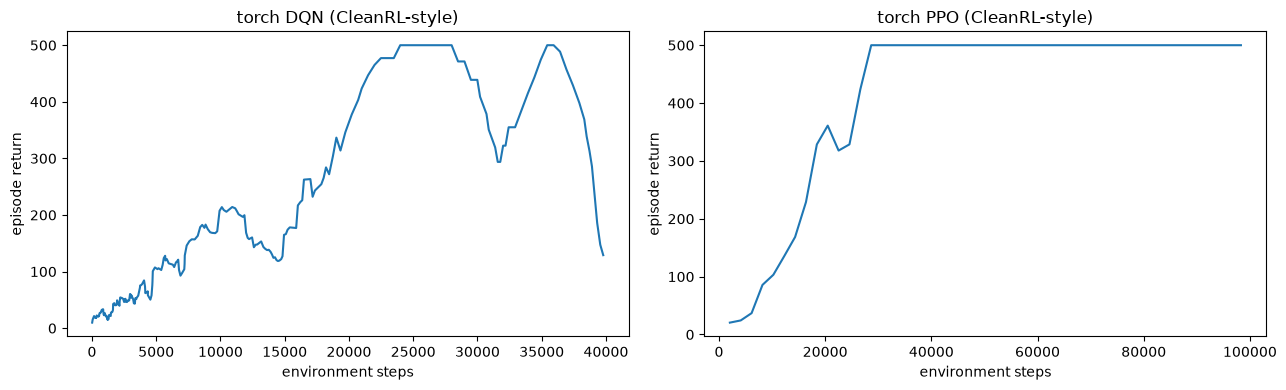

In [5]:
def ortho(layer, std=np.sqrt(2)):
    nn.init.orthogonal_(layer.weight, std); nn.init.zeros_(layer.bias); return layer

class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.critic = nn.Sequential(ortho(nn.Linear(4, 64)), nn.Tanh(), ortho(nn.Linear(64, 64)), nn.Tanh(), ortho(nn.Linear(64, 1), 1.0))
        self.actor = nn.Sequential(ortho(nn.Linear(4, 64)), nn.Tanh(), ortho(nn.Linear(64, 64)), nn.Tanh(), ortho(nn.Linear(64, 2), 0.01))
    def act(self, x, a=None):
        dist = torch.distributions.Categorical(logits=self.actor(x))
        if a is None:
            a = dist.sample()
        return a, dist.log_prob(a), dist.entropy(), self.critic(x).squeeze(-1)

def train_ppo_torch(total_steps=100_000, n_envs=4, n_steps=512, epochs=10, minibatch=64, lr=3e-4,
                    clip_eps=0.2, gamma=0.99, lam=0.95, seed=0):
    torch.manual_seed(seed)
    envs = gym.vector.SyncVectorEnv([lambda: gym.make("CartPole-v1") for _ in range(n_envs)],
                                    autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
    agent = ActorCritic(); opt = torch.optim.Adam(agent.parameters(), lr=lr, eps=1e-5)
    obs, _ = envs.reset(seed=seed); obs = torch.tensor(obs, dtype=torch.float32)
    ep_ret = np.zeros(n_envs); finished, log = [], []
    for it in range(total_steps // (n_envs * n_steps)):
        S = torch.zeros(n_steps, n_envs, 4); A = torch.zeros(n_steps, n_envs, dtype=torch.long)
        LP, R, V_, V_next, TERM, END = (torch.zeros(n_steps, n_envs) for _ in range(6))
        for t in range(n_steps):                                                     # 1. rollout
            with torch.no_grad():
                a, lp, _, v = agent.act(obs)
            o2, r, term, trunc, info = envs.step(a.numpy())
            true_next = torch.tensor(o2, dtype=torch.float32)
            if "final_obs" in info:                                                  # the real s' of finished envs
                for i in np.flatnonzero(info["_final_obs"]):
                    true_next[i] = torch.tensor(info["final_obs"][i], dtype=torch.float32)
            with torch.no_grad():
                V_next[t] = agent.critic(true_next).squeeze(-1)
            S[t], A[t], LP[t], V_[t], R[t] = obs, a, lp, v, torch.tensor(r)
            TERM[t] = torch.tensor(term, dtype=torch.float32); END[t] = torch.tensor(term | trunc, dtype=torch.float32)
            ep_ret += r
            for i in np.flatnonzero(term | trunc):
                finished.append(ep_ret[i]); ep_ret[i] = 0
            obs = torch.tensor(o2, dtype=torch.float32)
        END[-1] = 1.0                                                                # the batch cut ends the stream
        adv = torch.zeros(n_steps, n_envs); running = torch.zeros(n_envs)            # 2. GAE (notebook 5)
        for t in reversed(range(n_steps)):
            delta = R[t] + gamma * V_next[t] * (1 - TERM[t]) - V_[t]
            running = delta + gamma * lam * (1 - END[t]) * running
            adv[t] = running
        ret = adv + V_
        b_S, b_A, b_LP, b_adv, b_ret = (x.reshape(n_steps * n_envs, *x.shape[2:]) for x in (S, A, LP, adv, ret))
        for _ in range(epochs):                                                      # 3. K epochs of minibatches
            for mb in torch.randperm(n_steps * n_envs).split(minibatch):
                _, new_lp, ent, v = agent.act(b_S[mb], b_A[mb])
                ratio = (new_lp - b_LP[mb]).exp()
                mb_adv = (b_adv[mb] - b_adv[mb].mean()) / (b_adv[mb].std() + 1e-8)
                pg_loss = torch.max(-mb_adv * ratio, -mb_adv * ratio.clamp(1 - clip_eps, 1 + clip_eps)).mean()   # PPO-clip
                v_loss = 0.5 * ((v - b_ret[mb]) ** 2).mean()
                loss = pg_loss + 0.5 * v_loss
                opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(agent.parameters(), 0.5); opt.step()
        log.append(((it + 1) * n_envs * n_steps, np.mean(finished[-10:]) if finished else 0.0))
    return np.array(log)

t0 = time.time()
ppo_log = train_ppo_torch()
print(f"torch PPO, 100k steps: {time.time() - t0:.0f}s")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dqn_steps, np.convolve(dqn_returns, np.ones(10) / 10, "same")); axes[0].set_title("torch DQN (CleanRL-style)")
axes[1].plot(ppo_log[:, 0], ppo_log[:, 1]); axes[1].set_title("torch PPO (CleanRL-style)")
for ax in axes: ax.set_xlabel("environment steps"); ax.set_ylabel("episode return")
plt.tight_layout(); plt.show()

Same algorithms, same behavior as notebooks 4 and 6 (PPO reliably reaches
500; DQN gets there and wobbles), in a fraction of the code, because autograd
and `Categorical` replace our hand-written gradients.

| PPO concept (notebook 6) | line above |
|---|---|
| rollout with stored old log-probs | `a, lp, _, v = agent.act(obs)` under `no_grad` |
| bootstrap on truncation, not on termination | `V_next` from `final_obs`, masked by `TERM` |
| GAE, stopped at episode ends | the `running = delta + gamma*lam*(1-END)*running` loop |
| per-minibatch advantage normalization | `mb_adv = ...` |
| clipped surrogate | `torch.max(-A*ratio, -A*ratio.clamp(...))` (the max of negatives = min of positives) |
| gradient-norm clipping | `clip_grad_norm_(..., 0.5)` |

## B4. A real language model: generation and sequence log-probabilities

Everything LLM-RL needs from the model boils down to two operations:

1. **Sample** completions (the rollout).
2. Compute **$\log\pi_\theta(y\mid x) = \sum_t \log\pi_\theta(y_t\mid x, y_{<t})$** for given completions, *with
   gradients*. That's one forward pass over prompt + completion; the logits at
   position $t-1$ predict token $t$ ("shift by one").

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device for the LLM sections:", DEVICE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = "left"                     # left-pad prompts so generation continues on the right
lm = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32).to(DEVICE).eval()
print(f"{MODEL_NAME}: {sum(p.numel() for p in lm.parameters()) / 1e6:.0f}M parameters, vocabulary {lm.config.vocab_size:,}")

def chat_prompt(user_msg, system=None):
    msgs = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": user_msg}]
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

def sample_completions(model, prompts, max_new_tokens=32, temperature=0.8, seed=0):
    torch.manual_seed(seed)
    enc = tokenizer(prompts, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature,
                             top_k=0, pad_token_id=tokenizer.pad_token_id)
    return enc, out, tokenizer.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)

def completion_logprobs(model, sequences, attention_mask, n_prompt):
    '''Per-token log pi(y_t | x, y_<t) for the completion part of `sequences`.'''
    logits = model(input_ids=sequences, attention_mask=attention_mask).logits
    logits = logits[:, n_prompt - 1:-1]                             # position t-1 predicts token t
    targets = sequences[:, n_prompt:]
    return torch.log_softmax(logits.float(), dim=-1).gather(-1, targets[..., None]).squeeze(-1)

prompts = [chat_prompt("Give me one tip for learning to cook."), chat_prompt("What is 2+3? Reply with just the number.")]
enc, seqs, texts = sample_completions(lm, prompts)
for p, t in zip(["cooking tip", "2+3"], texts):
    print(f"--- {p}:\n{t.strip()}")

# the completion's log-probability = sum of token log-probs; check against step-by-step decoding
n_prompt = enc["input_ids"].shape[1]
completion = seqs[:, n_prompt:]
cmask = torch.ones_like(completion)
for i in range(len(completion)):                                     # mask everything after the first <eos>
    eos = (completion[i] == tokenizer.eos_token_id).nonzero()
    if len(eos): cmask[i, eos[0, 0] + 1:] = 0
attn = torch.cat([enc["attention_mask"], cmask], dim=1)
with torch.no_grad():
    tok_lp = completion_logprobs(lm, seqs, attn, n_prompt)
seq_lp = (tok_lp * cmask).sum(dim=1)
with torch.no_grad():                                                # brute force: one forward pass per token
    manual = 0.0
    for t in range(int(cmask[0].sum())):
        ctx = seqs[:1, :n_prompt + t]
        manual += torch.log_softmax(lm(input_ids=ctx, attention_mask=attn[:1, :n_prompt + t]).logits[0, -1].float(), -1)[seqs[0, n_prompt + t]].item()
print(f"\nlog pi(y|x) for the first completion: batched = {seq_lp[0].item():.4f},  token-by-token = {manual:.4f}")
assert abs(seq_lp[0].item() - manual) < 1e-2

device for the LLM sections: mps


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

HuggingFaceTB/SmolLM2-135M-Instruct: 135M parameters, vocabulary 49,152


--- cooking tip:
The key to cooking is to focus on one ingredient at a time, and to allow the flavor and texture of each ingredient to shine. 

Start by selecting
--- 2+3:
The answer to my question is that 2+3 equals 5. The answer is just 5.



log pi(y|x) for the first completion: batched = -40.2561,  token-by-token = -40.2561


## B5. RLHF, stage 2: a reward model with `trl.RewardTrainer`

Notebook 7's Bradley–Terry reward model, at LLM scale: a copy of the language
model with its vocabulary head replaced by a **single scalar output**
(`AutoModelForSequenceClassification` with `num_labels=1`), trained on
(prompt, chosen, rejected) triples with the loss $-\log\sigma(r_w - r_l)$.
`RewardTrainer` handles tokenization with the chat template, batching and
logging (`accuracy` = fraction of pairs ranked correctly, `margin` = mean
$r_w - r_l$).

Our preference data is a small hand-written set: helpful, polite answers
(chosen) vs. dismissive or rude ones (rejected). It's tiny, so the reward
model will learn a crude "helpful & polite vs. dismissive" direction — enough
to see every moving part.

In [7]:
from datasets import Dataset
from trl import RewardConfig, RewardTrainer

PREFS = [
    ("How do I boil an egg?", "Put the egg in boiling water for about 9 minutes, then cool it in cold water.", "Figure it out yourself."),
    ("What is the capital of France?", "The capital of France is Paris.", "Why should I tell you? Look it up."),
    ("How can I sleep better?", "Keep a regular schedule, avoid screens before bed, and limit caffeine after noon.", "Stop complaining and just sleep."),
    ("Can you help me write a thank-you note?", "Of course! Try: 'Thank you so much for your thoughtful gift, it made my day.'", "No. Write your own notes."),
    ("How do I start learning Python?", "Begin with a beginner tutorial, then build small projects like a to-do list app.", "You're probably too slow to learn Python."),
    ("My code has a bug, what should I do?", "Read the error message, reproduce the bug with a small example, and add print statements to narrow it down.", "Not my problem."),
    ("What's a healthy breakfast?", "Oatmeal with fruit and nuts, or eggs with whole-grain toast, are both good options.", "Whatever, eat anything."),
    ("How do I apologize to a friend?", "Be specific about what you did, take responsibility, and ask how you can make it right.", "Don't bother, they'll get over it."),
]
def to_messages(q, a):
    return [{"role": "user", "content": q}], [{"role": "assistant", "content": a}]
pref_ds = Dataset.from_list([{"prompt": to_messages(q, c)[0], "chosen": to_messages(q, c)[1], "rejected": to_messages(q, r)[1]}
                             for q, c, r in PREFS] * 4)

COMMON = dict(report_to="none", save_strategy="no", use_cpu=(DEVICE == "cpu"), logging_steps=5, seed=0)
reward_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1, dtype=torch.float32)
reward_model.config.pad_token_id = tokenizer.pad_token_id
t0 = time.time()
rm_trainer = RewardTrainer(
    model=reward_model,
    args=RewardConfig(output_dir="/tmp/nb10_rm", max_steps=15, per_device_train_batch_size=4, learning_rate=3e-5, **COMMON),
    train_dataset=pref_ds, processing_class=tokenizer)
rm_trainer.train()
print(f"reward model trained in {time.time() - t0:.0f}s")
for row in rm_trainer.state.log_history:
    if "loss" in row:
        print({k: round(row[k], 3) for k in ["step", "loss", "accuracy", "margin"] if k in row})
reward_model.eval()

def rm_score(user_msgs, responses):
    texts = [tokenizer.apply_chat_template([{"role": "user", "content": u}, {"role": "assistant", "content": r}], tokenize=False)
             for u, r in zip(user_msgs, responses)]
    enc = tokenizer(texts, return_tensors="pt", padding=True).to(reward_model.device)
    with torch.no_grad():
        return reward_model(**enc).logits[:, 0].float()

probe = ["How do I make tea?"] * 3
print("RM scores:", rm_score(probe, ["Boil water, steep the tea bag for 3-5 minutes, then add milk or sugar to taste.",
                                     "Just google it.", "I don't care about your tea."]).cpu().numpy().round(2))

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

[transformers] LlamaForSequenceClassification LOAD REPORT from: HuggingFaceTB/SmolLM2-135M-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizing train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Filtering train >1024 tokens:   0%|          | 0/32 [00:00<?, ? examples/s]

Step,Training Loss
5,0.561270
10,0.072427
15,0.010281


reward model trained in 14s
{'step': 5, 'loss': 0.561, 'accuracy': 0.65, 'margin': 0.369}
{'step': 10, 'loss': 0.072, 'accuracy': 1.0, 'margin': 2.908}
{'step': 15, 'loss': 0.01, 'accuracy': 1.0, 'margin': 4.764}


RM scores: [ 1.91 -3.34 -4.44]


## B6. RLHF, stage 3: token-level PPO for an LLM, written in PyTorch

This is `ppo_rlhf` from notebook 7, line for line, on a real transformer:

- **Policy** = the LM. **Reference** = a frozen copy. **Reward model** = B5.
- **Value head** = a linear layer on the policy's last hidden state (the
  classic `AutoModelForCausalLMWithValueHead` design; InstructGPT used a
  separate value model).
- **Per-token reward**: $-\beta\log\frac{\pi_{\text{old}}}{\pi_{\text{ref}}}$ on every completion token,
  plus the RM score on the last real token.
- **GAE** over token positions ($\gamma = 1$), **PPO-clip**, value loss.

With a 135M model on a laptop we run only a few iterations on four prompts. Watch
the mechanics — rewards, KL, the log — not the quality.

In [8]:
import copy
torch.manual_seed(0)
policy = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32).to(DEVICE)
reference = copy.deepcopy(policy).eval()
for p in reference.parameters():
    p.requires_grad_(False)
value_head = nn.Linear(policy.config.hidden_size, 1).to(DEVICE)
nn.init.zeros_(value_head.weight); nn.init.zeros_(value_head.bias)
optimizer = torch.optim.Adam(list(policy.parameters()) + list(value_head.parameters()), lr=2e-6)

def logprobs_and_values(model, seqs, attn, n_prompt, with_values):
    out = model(input_ids=seqs, attention_mask=attn, output_hidden_states=with_values)
    logits = out.logits[:, n_prompt - 1:-1]
    lp = torch.log_softmax(logits.float(), -1).gather(-1, seqs[:, n_prompt:, None]).squeeze(-1)
    values = value_head(out.hidden_states[-1][:, n_prompt - 1:-1]).squeeze(-1) if with_values else None
    return lp, values

TRAIN_PROMPTS = ["How do I make tea?", "Give me a tip for studying.", "How do I stay motivated?", "What should I cook tonight?"]
BETA, CLIP, LAM, EPOCHS = 0.05, 0.2, 0.95, 2
for it in range(5):
    t0 = time.time()
    # 1. rollout
    enc = tokenizer([chat_prompt(p) for p in TRAIN_PROMPTS], return_tensors="pt", padding=True).to(DEVICE)
    n_prompt = enc["input_ids"].shape[1]
    with torch.no_grad():
        seqs = policy.generate(**enc, max_new_tokens=24, do_sample=True, temperature=1.0, top_k=0, pad_token_id=tokenizer.pad_token_id)
    resp = seqs[:, n_prompt:]
    is_eos = resp == tokenizer.eos_token_id
    last = torch.where(is_eos.any(1), is_eos.float().argmax(1), torch.full((len(resp),), resp.shape[1] - 1, device=DEVICE))
    mask = (torch.arange(resp.shape[1], device=DEVICE)[None] <= last[:, None]).float()
    attn = torch.cat([enc["attention_mask"], mask.long()], dim=1)
    texts = tokenizer.batch_decode(resp, skip_special_tokens=True)
    with torch.no_grad():
        old_lp, old_v = logprobs_and_values(policy, seqs, attn, n_prompt, True)
        ref_lp, _ = logprobs_and_values(reference, seqs, attn, n_prompt, False)
        score = rm_score(TRAIN_PROMPTS, texts)
    # 2. per-token rewards: KL penalty everywhere, RM score at the last real token
    kl_tok = (old_lp - ref_lp) * mask
    rewards = -BETA * kl_tok
    rewards[torch.arange(len(resp), device=DEVICE), last] += score
    # 3. GAE over token positions (gamma = 1)
    values = old_v * mask
    adv = torch.zeros_like(rewards); running = torch.zeros(len(resp), device=DEVICE)
    for t in reversed(range(resp.shape[1])):
        next_v = values[:, t + 1] if t + 1 < resp.shape[1] else torch.zeros(len(resp), device=DEVICE)
        cont = mask[:, t + 1] if t + 1 < resp.shape[1] else torch.zeros(len(resp), device=DEVICE)
        running = rewards[:, t] + next_v - values[:, t] + LAM * cont * running
        adv[:, t] = running * mask[:, t]
    returns = adv + values
    adv_n = (adv - adv[mask.bool()].mean()) / (adv[mask.bool()].std() + 1e-8)
    # 4. PPO-clip epochs
    for _ in range(EPOCHS):
        lp, v = logprobs_and_values(policy, seqs, attn, n_prompt, True)
        ratio = (lp - old_lp).exp()
        pg = (torch.max(-adv_n * ratio, -adv_n * ratio.clamp(1 - CLIP, 1 + CLIP)) * mask).sum() / mask.sum()
        vf = 0.5 * (((v - returns) ** 2) * mask).sum() / mask.sum()
        optimizer.zero_grad(); (pg + 0.1 * vf).backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); optimizer.step()
    clipfrac = (((ratio - 1).abs() > CLIP).float() * mask).sum() / mask.sum()
    print(f"iter {it}: {time.time() - t0:5.1f}s | RM score {score.mean():6.3f} | KL {kl_tok.sum(1).mean():6.3f} | "
          f"clip frac {clipfrac:.3f} | e.g. {texts[0].strip()[:60]!r}")

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

iter 0:   5.5s | RM score -0.852 | KL  0.000 | clip frac 0.012 | e.g. "Making tea can be quite a labor of love, but I'll guide you "


iter 1:   1.6s | RM score  0.404 | KL  0.033 | clip frac 0.000 | e.g. 'Making your own tea is a delightful way to enjoy the benefit'


iter 2:   1.3s | RM score  0.845 | KL  0.110 | clip frac 0.000 | e.g. 'While we use the traditional method of steeping tea leaves i'


iter 3:   1.4s | RM score  0.523 | KL  0.089 | clip frac 0.000 | e.g. 'To brew a delicious and fragrant tea, follow these simple st'


iter 4:   1.3s | RM score  0.844 | KL  0.025 | clip frac 0.000 | e.g. 'Making Your Own Tea is a simple yet delightful way to start '


(The KL column can dip slightly below zero: it's the k1 estimate
$\sum_t \log\frac{\pi_{\text{old}}}{\pi_{\text{ref}}}$ on a handful of samples, and notebook 6 showed that k1 is unbiased but
can be negative on individual samples.)

Every quantity from notebook 7's `ppo_rlhf` is here: rollout, old/ref
log-probs, per-token KL reward, terminal RM score, GAE, clipped ratio, value
loss, gradient clipping. A real run uses hundreds of prompts per batch, a
separate value model, a KL controller, and thousands of iterations on GPUs.
The structure is the same.

## B7. DPO with `trl.DPOTrainer`

The same preference data as B5, used directly on the policy (Part A's loss).
`DPOTrainer` creates the reference model automatically (a frozen copy), and
logs exactly the quantities we plotted in Part A:

| `trl` log key | Part A quantity |
|---|---|
| `rewards/chosen`, `rewards/rejected` | $\beta\log\frac{\pi_\theta(y)}{\pi_{\text{ref}}(y)}$ for chosen / rejected |
| `rewards/margins` | $z/\beta \cdot \beta$ — the implicit reward margin |
| `rewards/accuracies` | fraction of pairs with $z > 0$ |
| `logps/chosen`, `logps/rejected` | $\log\pi_\theta(y\mid x)$ — watch for likelihood displacement |

In [9]:
from trl import DPOConfig, DPOTrainer
dpo_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
t0 = time.time()
dpo_trainer = DPOTrainer(
    model=dpo_model,
    args=DPOConfig(output_dir="/tmp/nb10_dpo", beta=0.1, max_steps=10, per_device_train_batch_size=4, learning_rate=5e-6, **COMMON),
    train_dataset=pref_ds, processing_class=tokenizer)
dpo_trainer.train()
print(f"DPO: {time.time() - t0:.0f}s")
for row in dpo_trainer.state.log_history:
    if "loss" in row:
        print({k: round(float(row[k]), 4) for k in ["step", "loss", "rewards/chosen", "rewards/rejected", "rewards/accuracies", "logps/chosen", "logps/rejected"] if k in row})

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Dropping fully truncated examples from train dataset:   0%|          | 0/32 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Step,Training Loss
5,0.690411
10,0.659402


DPO: 14s
{'step': 5.0, 'loss': 0.6904, 'rewards/chosen': 0.017, 'rewards/rejected': 0.0111, 'rewards/accuracies': 0.5, 'logps/chosen': -53.0403, 'logps/rejected': -36.9932}
{'step': 10.0, 'loss': 0.6594, 'rewards/chosen': 0.0516, 'rewards/rejected': -0.0175, 'rewards/accuracies': 0.9, 'logps/chosen': -49.7886, 'logps/rejected': -35.1924}


## B8. GRPO (and RLOO) with verifiable rewards

Notebooks 8–9 on a real model: prompts "What is a+b? Reply with only the
number.", and a **verifier** as the reward function. `GRPOTrainer` does the
sampling, grouping, advantages, clipping and KL for us. Our numpy `grpo_train`
arguments map one to one (see notebook 9, Section 7).

`trl`'s reward functions receive the completions (plus any extra dataset
columns, like `answer` here) and return one float per completion.

In [10]:
import re
from trl import GRPOConfig, GRPOTrainer, RLOOConfig, RLOOTrainer

math_ds = Dataset.from_list([{"prompt": [{"role": "user", "content": f"What is {a}+{b}? Reply with only the number."}],
                              "answer": str(a + b)} for a in range(10) for b in range(10)]).shuffle(seed=0)

def correctness_reward(completions, answer, **kwargs):
    '''The verifier (notebook 8): 1.0 iff the LAST number in the reply is the right answer.

    Why the last number? Small chat models often restate the question ("2+3 is 5"), so the FIRST
    number is usually an operand. A verifier must match how the model actually answers -- and
    must not be so lenient that it can be hacked (e.g. "the answer appears anywhere": notebook 8, Sec. 5).'''
    rewards = []
    for completion, ans in zip(completions, answer):
        numbers = re.findall(r"-?\d+", completion[0]["content"])
        rewards.append(1.0 if numbers[-1:] == [ans] else 0.0)
    return rewards

print("verifier check:", correctness_reward([[{"content": "2+3 is 5."}], [{"content": "The answer is 6"}]], ["5", "5"]))

grpo_args = GRPOConfig(
    output_dir="/tmp/nb10_grpo",
    num_generations=4,            # G: group size
    max_completion_length=16,
    scale_rewards=False,          # Dr. GRPO: don't divide by the group std       (notebook 9, Sec. 3)
    loss_type="dr_grpo",          # constant normalizer, no 1/|o_i|                (notebook 9, Sec. 4)
    beta=0.0,                     # no KL term / no reference model                (notebook 9, Sec. 5)
    epsilon=0.2, epsilon_high=0.28,   # clip-higher                                (notebook 9, Sec. 4)
    max_steps=12, per_device_train_batch_size=8, learning_rate=5e-6, temperature=1.0, **{**COMMON, "logging_steps": 1})
t0 = time.time()
grpo_trainer = GRPOTrainer(model=AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32), reward_funcs=correctness_reward,
                           args=grpo_args, train_dataset=math_ds, processing_class=tokenizer)
grpo_trainer.train()
print(f"GRPO: {time.time() - t0:.0f}s")
for row in grpo_trainer.state.log_history:
    if "reward" in row:
        print({k: round(float(row[k]), 3) for k in ["step", "reward", "reward_std", "frac_reward_zero_std", "entropy", "completions/mean_length", "clip_ratio/region_mean"] if k in row})

verifier check: [1.0, 0.0]


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Step,Training Loss
1,0.039062
2,0.044922
3,0.033203
4,0.095703
5,-0.031250
6,0.066406
7,-0.007812
8,0.066406
9,0.082031
10,0.013672


GRPO: 24s
{'step': 1.0, 'reward': 0.25, 'reward_std': 0.463, 'frac_reward_zero_std': 0.0, 'entropy': 1.644, 'completions/mean_length': 14.5, 'clip_ratio/region_mean': 0.0}
{'step': 2.0, 'reward': 0.375, 'reward_std': 0.518, 'frac_reward_zero_std': 0.0, 'entropy': 1.708, 'completions/mean_length': 12.375, 'clip_ratio/region_mean': 0.0}
{'step': 3.0, 'reward': 0.125, 'reward_std': 0.354, 'frac_reward_zero_std': 0.5, 'entropy': 1.237, 'completions/mean_length': 12.875, 'clip_ratio/region_mean': 0.0}
{'step': 4.0, 'reward': 0.375, 'reward_std': 0.518, 'frac_reward_zero_std': 0.0, 'entropy': 1.581, 'completions/mean_length': 12.875, 'clip_ratio/region_mean': 0.0}
{'step': 5.0, 'reward': 0.5, 'reward_std': 0.535, 'frac_reward_zero_std': 0.0, 'entropy': 1.342, 'completions/mean_length': 12.25, 'clip_ratio/region_mean': 0.0}
{'step': 6.0, 'reward': 0.75, 'reward_std': 0.463, 'frac_reward_zero_std': 0.0, 'entropy': 1.282, 'completions/mean_length': 11.75, 'clip_ratio/region_mean': 0.0}
{'step':

In [11]:
rloo_args = RLOOConfig(output_dir="/tmp/nb10_rloo", num_generations=4, max_completion_length=16, beta=0.0,
                       max_steps=6, per_device_train_batch_size=8, learning_rate=5e-6, **{**COMMON, "logging_steps": 1})
t0 = time.time()
rloo_trainer = RLOOTrainer(model=AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32), reward_funcs=correctness_reward,
                           args=rloo_args, train_dataset=math_ds, processing_class=tokenizer)
rloo_trainer.train()
print(f"RLOO: {time.time() - t0:.0f}s")
for row in rloo_trainer.state.log_history:
    if "reward" in row:
        print({k: round(float(row[k]), 3) for k in ["step", "reward", "reward_std", "frac_reward_zero_std", "completions/mean_length"] if k in row})

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Step,Training Loss
1,-0.009175
2,-0.017389
3,0.000571
4,0.002664
5,0.016984
6,-0.049833


RLOO: 14s
{'step': 1.0, 'reward': 0.25, 'reward_std': 0.463, 'frac_reward_zero_std': 0.0, 'completions/mean_length': 14.5}
{'step': 2.0, 'reward': 0.375, 'reward_std': 0.518, 'frac_reward_zero_std': 0.0, 'completions/mean_length': 13.5}
{'step': 3.0, 'reward': 0.125, 'reward_std': 0.354, 'frac_reward_zero_std': 0.5, 'completions/mean_length': 12.75}
{'step': 4.0, 'reward': 0.375, 'reward_std': 0.518, 'frac_reward_zero_std': 0.0, 'completions/mean_length': 12.875}
{'step': 5.0, 'reward': 0.5, 'reward_std': 0.535, 'frac_reward_zero_std': 0.0, 'completions/mean_length': 13.375}
{'step': 6.0, 'reward': 0.75, 'reward_std': 0.463, 'frac_reward_zero_std': 0.0, 'completions/mean_length': 10.75}


A handful of steps won't move accuracy much. What to look at in these logs
(the same diagnostics as notebooks 6–9):

| log key | meaning | notebook |
|---|---|---|
| `reward`, `reward_std` | mean verifier reward, spread within groups | 8 |
| `frac_reward_zero_std` | fraction of groups with no signal (all right / all wrong) | 8 §4, 9 §4 |
| `entropy` | policy entropy — watch for collapse | 5 §8, 9 §4 |
| `completions/mean_length` | response length — watch for length drift / hacking | 8 §5, 9 §4 |
| `clip_ratio/*` | fraction of tokens clipped | 6 §7 |
| `kl` (when `beta > 0`) | KL to the reference model | 6, 7 |

## B9. Scaling up: what changes in a real run

- **Hardware / memory.** Use GPUs (`use_cpu=False`), `bf16=True`, gradient
  checkpointing, and **LoRA** (`peft.LoraConfig`, passed as
  `peft_config=` to any `trl` trainer). With LoRA, the reference model is just
  "the base model with adapters disabled," so it costs no extra memory.
- **Generation speed.** Rollouts dominate RL cost (notebook 6, Section 1).
  `trl` can generate with **vLLM** (`use_vllm=True`), which is often 10× faster than
  `model.generate`.
- **Batch sizes.** Real GRPO runs use hundreds of prompts × 8–64 generations
  per step, and completions of thousands of tokens.
- **Monitoring.** Always evaluate on a held-out set with a metric you are *not*
  optimizing (notebooks 7–8): human or LLM-judge evaluations for RLHF, strict
  verifiers and pass@k for RLVR.

## Recap & exercises

**Part A:** DPO derived from the KL-regularized optimum: the partition
function cancels in Bradley–Terry differences, and the implicit reward
$\beta\log\frac{\pi_\theta}{\pi_{\text{ref}}}$ is trained directly. Implemented from scratch, with
Goodhart dynamics at small $\beta$ and likelihood displacement.

**Part B:** PyTorch autograd reproduces our backprop exactly. CleanRL-style DQN
and PPO on gymnasium. Sequence log-probs of a real LLM. A reward model with
`RewardTrainer`. InstructGPT-style PPO written by hand. DPO, GRPO and RLOO
with `trl` — each mapped back to the from-scratch notebooks.

**Next — Notebook 11: RLCD.** Everything above needs preference pairs or a
verifier. RLCD shows how to *generate* high-quality preference pairs with no
labeler at all, and plugs them into this exact pipeline.

### Exercises

1. **IPO.** Replace DPO's $-\log\sigma(z)$ with IPO's squared loss
   $(z/\beta - \frac{1}{2\beta})^2$ in the numpy `dpo`. Does likelihood displacement
   shrink? Try `DPOConfig(loss_type="ipo")` in `trl`.
2. **Online DPO.** Every 50 steps, regenerate the pairs from the *current*
   policy (and relabel them with the rater). Does small $\beta$ still collapse?
3. **LoRA.** Pass `peft_config=LoraConfig(r=16, lora_alpha=32, target_modules="all-linear")` to
   `DPOTrainer` and `GRPOTrainer`. Compare the number of trainable parameters and
   the time per step.
4. **Longer GRPO.** On a GPU, run the B8 GRPO for 200 steps with
   `num_generations=8`. Plot `reward` and `completions/mean_length`, and compare
   `loss_type="grpo"` with `"dr_grpo"`.
5. **PPO with a separate value model.** Replace the value head in B6 with a
   separate `AutoModelForSequenceClassification` critic, as InstructGPT did. What
   changes in memory and in the value-loss curve?